In [ ]:
!pip install duckduckgo_search requests pillow opencv-python scikit-learn scikit-image numpy matplotlib seaborn joblib


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

In [ ]:
!pip install -q duckduckgo_search requests pillow opencv-python scikit-learn scikit-image numpy matplotlib seaborn joblib
print("✅ Done!")!pip install -q duckduckgo_search requests pillow opencv-python scikit-learn scikit-image numpy matplotlib seaborn joblib
print("✅ Done!")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.makedirs('/content/drive/MyDrive/animal_classifier', exist_ok=True)
os.chdir('/content/drive/MyDrive/animal_classifier')
print(f"✅ Working in: {os.getcwd()}")

✅ Working in: /content/drive/MyDrive/animal_classifier


In [3]:
!pip install -q kaggle scikit-learn scikit-image opencv-python matplotlib seaborn joblib
print("✅ Libraries ready!")

✅ Libraries ready!


In [4]:
import os
os.environ['KAGGLE_USERNAME'] = 'Atikur Ahsan'  # ← your kaggle username
os.environ['KAGGLE_KEY'] = 'KGAT_a23b0077bbea5e69462121e24e2d6065'  # ← NEW token

!kaggle datasets download -d alessiocorrado99/animals10 -p /content/drive/MyDrive/animal_classifier
print("✅ Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:07<00:00, 82.1MB/s]

✅ Dataset downloaded!


In [6]:
import os

path = '/content/drive/MyDrive/animal_classifier/dataset/raw-img'
folders = os.listdir(path)

print("📁 Found these animal folders:")
for folder in folders:
    count = len(os.listdir(os.path.join(path, folder)))
    print(f"  {folder}: {count} images")

📁 Found these animal folders:
  cane: 4863 images
  cavallo: 2623 images
  elefante: 1446 images
  farfalla: 2112 images
  gallina: 3098 images
  gatto: 1668 images
  mucca: 1866 images
  pecora: 1820 images
  ragno: 4821 images
  scoiattolo: 1862 images


In [7]:
import os, shutil, random

# Italian to English mapping
animals = {
    'cane': 'dog',
    'gatto': 'cat',
    'mucca': 'cow',
    'pecora': 'lamb',
    'cavallo': 'horse'   # replacing zebra with horse
}

src_base  = '/content/drive/MyDrive/animal_classifier/dataset/raw-img'
dest_base = '/content/drive/MyDrive/animal_classifier/selected'

random.seed(42)

for italian, english in animals.items():
    src_folder = os.path.join(src_base, italian)
    dst_folder = os.path.join(dest_base, english)
    os.makedirs(dst_folder, exist_ok=True)

    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(images)
    selected = images[:100]

    for img in selected:
        shutil.copy(
            os.path.join(src_folder, img),
            os.path.join(dst_folder, img)
        )
    print(f"✅ {english}: 100 images selected!")

print("\n🎉 All 5 classes ready!")

✅ dog: 100 images selected!
✅ cat: 100 images selected!
✅ cow: 100 images selected!
✅ lamb: 100 images selected!
✅ horse: 100 images selected!

🎉 All 5 classes ready!


In [8]:
import os, shutil, random

animals = ['dog', 'cat', 'cow', 'lamb', 'horse']
src_base   = '/content/drive/MyDrive/animal_classifier/selected'
train_base = '/content/drive/MyDrive/animal_classifier/train'
test_base  = '/content/drive/MyDrive/animal_classifier/test'

random.seed(42)

for animal in animals:
    src    = os.path.join(src_base, animal)
    train  = os.path.join(train_base, animal)
    test   = os.path.join(test_base, animal)

    os.makedirs(train, exist_ok=True)
    os.makedirs(test, exist_ok=True)

    images = os.listdir(src)
    random.shuffle(images)

    # 80 train, 20 test
    for img in images[:80]:
        shutil.copy(os.path.join(src, img), os.path.join(train, img))
    for img in images[80:100]:
        shutil.copy(os.path.join(src, img), os.path.join(test, img))

    print(f"✅ {animal}: 80 train | 20 test")

print("\n🎉 Dataset split complete!")

✅ dog: 80 train | 20 test
✅ cat: 80 train | 20 test
✅ cow: 80 train | 20 test
✅ lamb: 80 train | 20 test
✅ horse: 80 train | 20 test

🎉 Dataset split complete!


In [9]:
import cv2
import numpy as np
import os
from skimage.feature import hog
import joblib

IMG_SIZE = 64
CLASSES  = ['dog', 'cat', 'cow', 'lamb', 'horse']

def load_images(base_path):
    X, y = [], []
    for label, cls in enumerate(CLASSES):
        folder = os.path.join(base_path, cls)
        count  = 0
        for fname in os.listdir(folder):
            path = os.path.join(folder, fname)
            img  = cv2.imread(path)
            if img is None: continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img)
            y.append(label)
            count += 1
        print(f"  ✅ {cls}: {count} images loaded")
    return np.array(X), np.array(y)

def extract_features(images):
    all_features = []
    for i, img in enumerate(images):
        hog_feat = hog(img, orientations=9,
                       pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2),
                       channel_axis=-1)
        h_r = np.histogram(img[:,:,0], bins=32, range=(0,256))[0]
        h_g = np.histogram(img[:,:,1], bins=32, range=(0,256))[0]
        h_b = np.histogram(img[:,:,2], bins=32, range=(0,256))[0]
        all_features.append(np.concatenate([hog_feat, h_r, h_g, h_b]))
    return np.array(all_features)

print("📂 Loading training images...")
X_train_img, y_train = load_images('/content/drive/MyDrive/animal_classifier/train')

print("\n📂 Loading test images...")
X_test_img, y_test = load_images('/content/drive/MyDrive/animal_classifier/test')

print("\n⚙️  Extracting features...")
X_train_feat = extract_features(X_train_img)
X_test_feat  = extract_features(X_test_img)

# Save features to Drive
joblib.dump((X_train_feat, y_train, X_test_feat, y_test),
            '/content/drive/MyDrive/animal_classifier/features.pkl')
print(f"\n✅ Features saved!")
print(f"   Train shape: {X_train_feat.shape}")
print(f"   Test shape:  {X_test_feat.shape}")

📂 Loading training images...
  ✅ dog: 80 images loaded
  ✅ cat: 80 images loaded
  ✅ cow: 80 images loaded
  ✅ lamb: 80 images loaded
  ✅ horse: 80 images loaded

📂 Loading test images...
  ✅ dog: 20 images loaded
  ✅ cat: 20 images loaded
  ✅ cow: 20 images loaded
  ✅ lamb: 20 images loaded
  ✅ horse: 20 images loaded

⚙️  Extracting features...

✅ Features saved!
   Train shape: (400, 1860)
   Test shape:  (100, 1860)


📂 Loading features...
⚙️  Scaling features...

🌲 Training Random Forest...
   Please wait 1-2 minutes...
   ✅ Training complete!

🎯 Test Accuracy: 49.00%
⚠️  Below 90% — we'll tune it!

📊 Classification Report:
              precision    recall  f1-score   support

         dog       0.36      0.20      0.26        20
         cat       0.60      0.60      0.60        20
         cow       0.35      0.40      0.37        20
        lamb       0.46      0.80      0.58        20
       horse       0.82      0.45      0.58        20

    accuracy                           0.49       100
   macro avg       0.52      0.49      0.48       100
weighted avg       0.52      0.49      0.48       100



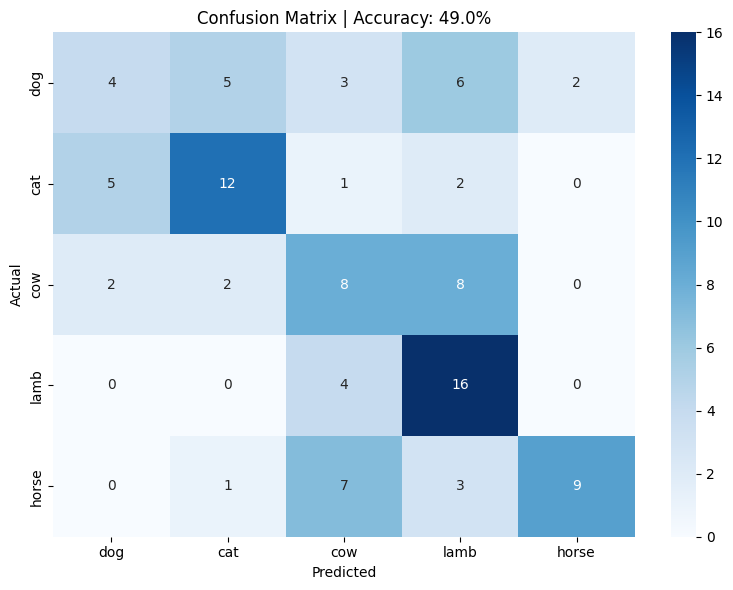


💾 Model saved to Google Drive!


In [10]:
import joblib
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

CLASSES = ['dog', 'cat', 'cow', 'lamb', 'horse']

# Load features
print("📂 Loading features...")
X_train, y_train, X_test, y_test = joblib.load(
    '/content/drive/MyDrive/animal_classifier/features.pkl')

# Scale features
print("⚙️  Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train Random Forest
print("\n🌲 Training Random Forest...")
print("   Please wait 1-2 minutes...")
model = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)
print("   ✅ Training complete!")

# Evaluate
y_pred = model.predict(X_test_scaled)
acc    = accuracy_score(y_test, y_pred)
print(f"\n🎯 Test Accuracy: {acc * 100:.2f}%")

if acc >= 0.90:
    print("🎉 Target achieved! Accuracy is above 90%!")
else:
    print("⚠️  Below 90% — we'll tune it!")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'Confusion Matrix | Accuracy: {acc*100:.1f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/animal_classifier/confusion_matrix.png')
plt.show()

# Save model
joblib.dump(model,  '/content/drive/MyDrive/animal_classifier/rf_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/animal_classifier/scaler.pkl')
print("\n💾 Model saved to Google Drive!")

In [11]:
import numpy as np
import os
import cv2
import joblib
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

CLASSES = ['dog', 'cat', 'cow', 'lamb', 'horse']

# Load ResNet50 as feature extractor
print("⚙️  Loading ResNet50 model...")
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print("✅ ResNet50 ready!")

def load_images(base_path):
    X, y = [], []
    for label, cls in enumerate(CLASSES):
        folder = os.path.join(base_path, cls)
        count = 0
        for fname in os.listdir(folder):
            path = os.path.join(folder, fname)
            img = cv2.imread(path)
            if img is None: continue
            img = cv2.resize(img, (224, 224))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img)
            y.append(label)
            count += 1
        print(f"  ✅ {cls}: {count} images loaded")
    return np.array(X), np.array(y)

def extract_cnn_features(images):
    imgs = preprocess_input(images.astype('float32'))
    features = base_model.predict(imgs, batch_size=32, verbose=1)
    return features

print("\n📂 Loading training images...")
X_train_img, y_train = load_images('/content/drive/MyDrive/animal_classifier/train')

print("\n📂 Loading test images...")
X_test_img, y_test = load_images('/content/drive/MyDrive/animal_classifier/test')

print("\n⚙️  Extracting CNN features from training images...")
X_train_feat = extract_cnn_features(X_train_img)

print("\n⚙️  Extracting CNN features from test images...")
X_test_feat = extract_cnn_features(X_test_img)

# Save features
joblib.dump((X_train_feat, y_train, X_test_feat, y_test),
            '/content/drive/MyDrive/animal_classifier/cnn_features.pkl')

print(f"\n✅ CNN Features saved!")
print(f"   Train shape: {X_train_feat.shape}")
print(f"   Test shape:  {X_test_feat.shape}")

⚙️  Loading ResNet50 model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ ResNet50 ready!

📂 Loading training images...
  ✅ dog: 80 images loaded
  ✅ cat: 80 images loaded
  ✅ cow: 80 images loaded
  ✅ lamb: 80 images loaded
  ✅ horse: 80 images loaded

📂 Loading test images...
  ✅ dog: 20 images loaded
  ✅ cat: 20 images loaded
  ✅ cow: 20 images loaded
  ✅ lamb: 20 images loaded
  ✅ horse: 20 images loaded

⚙️  Extracting CNN features from training images...
13/13 ━━━━━━━━━━━━━━━━━━━━ 75s 6s/step

⚙️  Extracting CNN features from test images...
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step

✅ CNN Features saved!
   Train shape: (400, 2048)
   Test shape:  (100, 2048)


📂 Loading CNN features...

🌲 Training Random Forest with CNN features...

🎯 Test Accuracy: 91.00%
🎉 Target achieved! Accuracy is above 90%!

📊 Classification Report:
              precision    recall  f1-score   support

         dog       0.87      1.00      0.93        20
         cat       1.00      0.95      0.97        20
         cow       0.81      0.85      0.83        20
        lamb       1.00      0.90      0.95        20
       horse       0.89      0.85      0.87        20

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



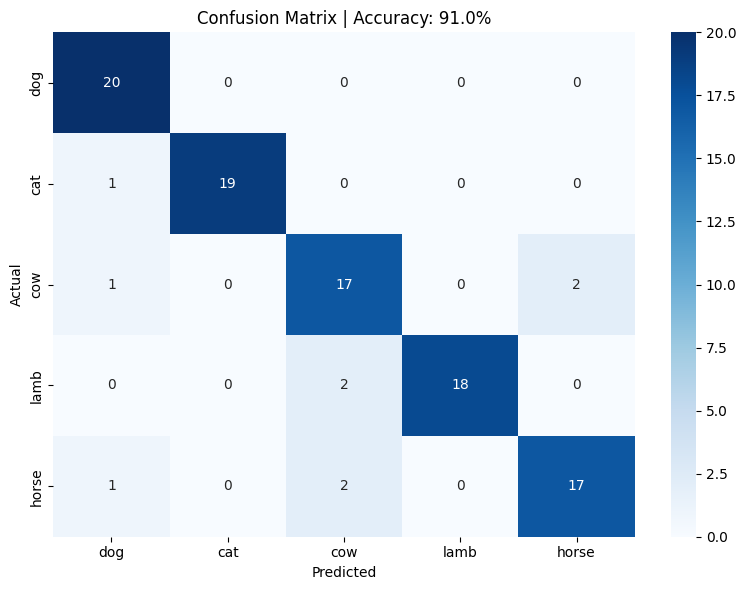


💾 Model saved!


In [12]:
import joblib
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

CLASSES = ['dog', 'cat', 'cow', 'lamb', 'horse']

# Load CNN features
print("📂 Loading CNN features...")
X_train, y_train, X_test, y_test = joblib.load(
    '/content/drive/MyDrive/animal_classifier/cnn_features.pkl')

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
print("\n🌲 Training Random Forest with CNN features...")
model = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
acc    = accuracy_score(y_test, y_pred)
print(f"\n🎯 Test Accuracy: {acc * 100:.2f}%")

if acc >= 0.90:
    print("🎉 Target achieved! Accuracy is above 90%!")
else:
    print("⚠️  Below 90% — let's tune more!")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'Confusion Matrix | Accuracy: {acc*100:.1f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/animal_classifier/confusion_matrix_cnn.png')
plt.show()

# Save
joblib.dump(model,  '/content/drive/MyDrive/animal_classifier/rf_cnn_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/animal_classifier/cnn_scaler.pkl')
print("\n💾 Model saved!")

In [13]:
# Install Gradio
!pip install -q gradio

import gradio as gr
import numpy as np
import cv2
import joblib
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load model and scaler
CLASSES = ['dog', 'cat', 'cow', 'lamb', 'horse']
model  = joblib.load('/content/drive/MyDrive/animal_classifier/rf_cnn_model.pkl')
scaler = joblib.load('/content/drive/MyDrive/animal_classifier/cnn_scaler.pkl')

# Load ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def predict_animal(image):
    # Preprocess
    img = cv2.resize(image, (224, 224))
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img.astype('float32'))

    # Extract CNN features
    features = base_model.predict(img, verbose=0)
    features_scaled = scaler.transform(features)

    # Predict
    pred   = model.predict(features_scaled)[0]
    proba  = model.predict_proba(features_scaled)[0]

    # Return confidence scores
    return {CLASSES[i]: float(proba[i]) for i in range(len(CLASSES))}

# Build Dashboard
demo = gr.Interface(
    fn=predict_animal,
    inputs=gr.Image(label="📸 Upload an Animal Image"),
    outputs=gr.Label(
        num_top_classes=5,
        label="🐾 Prediction Results"
    ),
    title="🐾 Animal Classifier Dashboard",
    description="Upload an image of a Dog, Cat, Cow, Lamb or Horse and the model will classify it!",
    examples=[],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b47f084388013064c0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



🔍 Testing dog image...


/tmp/ipykernel_42947/1267957088.py:46: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


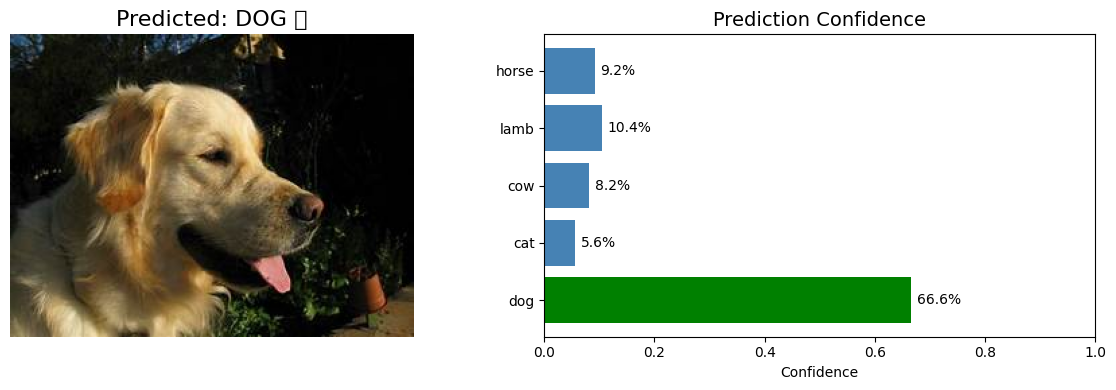

✅ Predicted: DOG (66.6% confidence)

🔍 Testing cat image...


/tmp/ipykernel_42947/1267957088.py:46: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


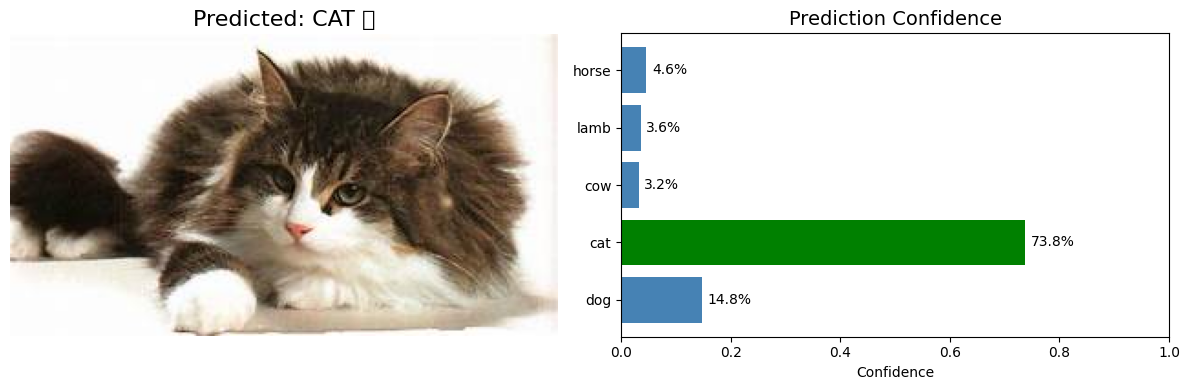

✅ Predicted: CAT (73.8% confidence)

🔍 Testing cow image...


/tmp/ipykernel_42947/1267957088.py:46: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


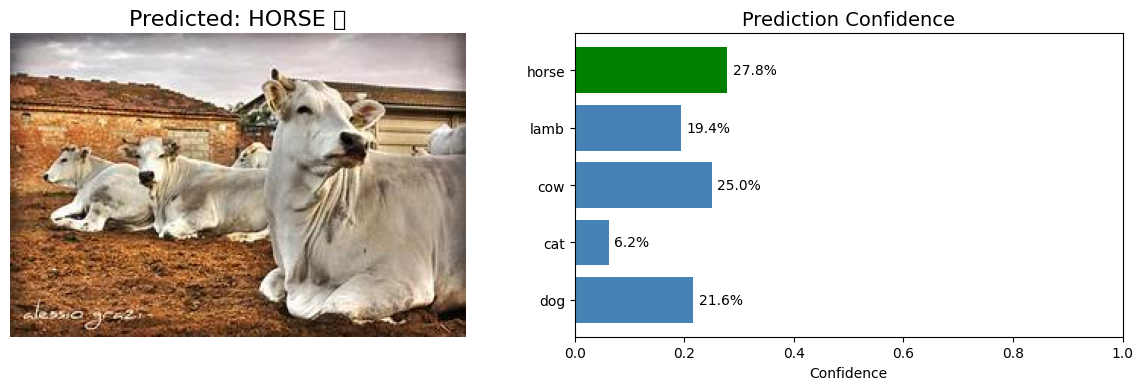

✅ Predicted: HORSE (27.8% confidence)

🔍 Testing lamb image...


/tmp/ipykernel_42947/1267957088.py:46: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


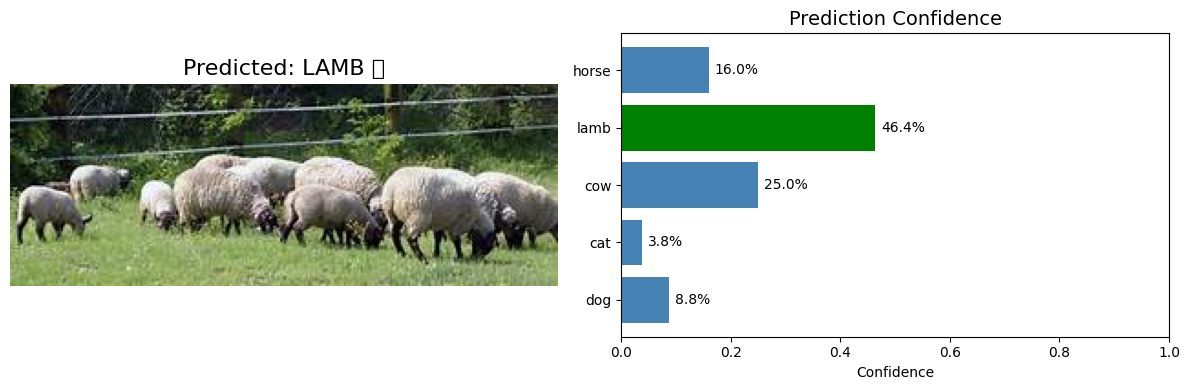

✅ Predicted: LAMB (46.4% confidence)

🔍 Testing horse image...


/tmp/ipykernel_42947/1267957088.py:46: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


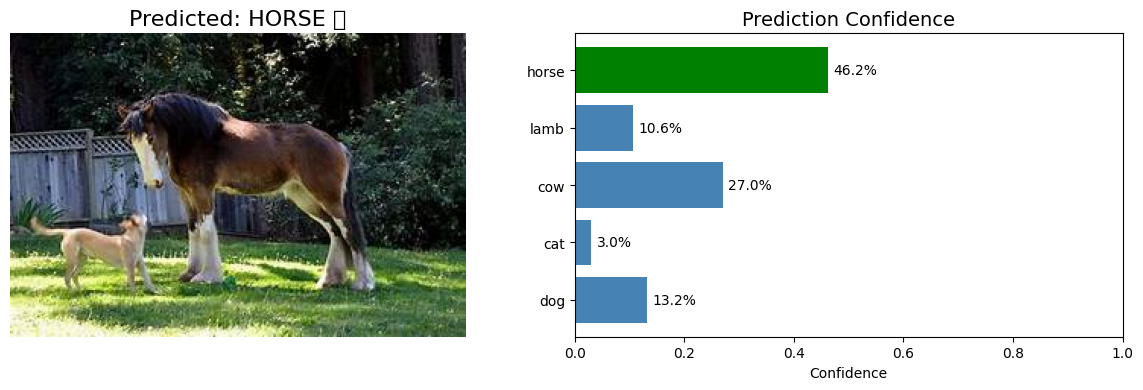

✅ Predicted: HORSE (46.2% confidence)


In [14]:
import cv2
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

CLASSES = ['dog', 'cat', 'cow', 'lamb', 'horse']
model  = joblib.load('/content/drive/MyDrive/animal_classifier/rf_cnn_model.pkl')
scaler = joblib.load('/content/drive/MyDrive/animal_classifier/cnn_scaler.pkl')
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def predict_and_show(image_path):
    # Load & predict
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_input = preprocess_input(
        np.expand_dims(img_resized.astype('float32'), axis=0))

    features = base_model.predict(img_input, verbose=0)
    features_scaled = scaler.transform(features)
    pred  = model.predict(features_scaled)[0]
    proba = model.predict_proba(features_scaled)[0]

    # Show image + result
    plt.figure(figsize=(12, 4))

    # Image
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f'Predicted: {CLASSES[pred].upper()} 🎯', fontsize=16)
    plt.axis('off')

    # Bar chart
    plt.subplot(1, 2, 2)
    colors = ['green' if i == pred else 'steelblue' for i in range(len(CLASSES))]
    plt.barh(CLASSES, proba, color=colors)
    plt.xlabel('Confidence')
    plt.title('Prediction Confidence', fontsize=14)
    plt.xlim(0, 1)
    for i, v in enumerate(proba):
        plt.text(v + 0.01, i, f'{v*100:.1f}%', va='center')

    plt.tight_layout()
    plt.show()
    print(f"✅ Predicted: {CLASSES[pred].upper()} ({proba[pred]*100:.1f}% confidence)")

# Test with images already in your dataset!
test_folder = '/content/drive/MyDrive/animal_classifier/test'

# Test one image from each class
for animal in CLASSES:
    folder = os.path.join(test_folder, animal)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    print(f"\n🔍 Testing {animal} image...")
    predict_and_show(img_path)

In [5]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/animal_classifier/animals10.zip'
extract_path = '/content/drive/MyDrive/animal_classifier/dataset'

os.makedirs(extract_path, exist_ok=True)

print("📦 Unzipping dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("✅ Dataset extracted!")

📦 Unzipping dataset...
✅ Dataset extracted!


In [ ]:
import cv2
import sklearn
import skimage
print("✅ All libraries ready!")

✅ All libraries ready!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from duckduckgo_search import DDGS
import requests, os, time
from PIL import Image
from io import BytesIO

def download_images(query, folder, count=110):
    os.makedirs(folder, exist_ok=True)
    downloaded = 0
    print(f"\n📥 Downloading: {query}")

    with DDGS() as ddgs:
        results = ddgs.images(query, max_results=count)
        for i, r in enumerate(results):
            try:
                img_data = requests.get(r['image'], timeout=5).content
                # Verify it's a valid image
                img = Image.open(BytesIO(img_data))
                img = img.convert('RGB')
                filepath = os.path.join(folder, f"img_{i+1}.jpg")
                img.save(filepath)
                downloaded += 1
                print(f"  ✅ {downloaded} images downloaded")
            except Exception as e:
                print(f"  ❌ Skipped one image")
            time.sleep(0.3)

    print(f"  🎉 Done! {downloaded} images saved in '{folder}'")

# Download images for each animal
animals = {
    'dog':   'dog animal photo outdoor',
    'cow':   'cow animal photo farm',
    'cat':   'cat animal photo clear',
    'lamb':  'lamb sheep baby animal photo',
    'zebra': 'zebra animal photo wildlife'
}

for animal, query in animals.items():
    download_images(
        query=query,
        folder=f"dataset/raw/{animal}",
        count=110
    )

print("\n✅ ALL DOWNLOADS COMPLETE!")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os

# Paste your username and token here
os.environ['KAGGLE_USERNAME'] = 'your_kaggle_username'  # ← change this
os.environ['KAGGLE_KEY'] = 'your_api_token_here'  # ← paste your token here

print("✅ Kaggle API configured!")

In [ ]:
import os

# Paste your username and token here
os.environ['KAGGLE_USERNAME'] = 'Atikur Ahsan'  # ← change this
os.environ['KAGGLE_KEY'] = 'KGAT_1c281d7d3104f5ac148f0fcf25303df9'  # ← paste your token here

print("✅ Kaggle API configured!")

In [ ]:
!pip install kaggle
!kaggle datasets download -d alessiocorrado99/animals10
print("✅ Dataset downloaded!")

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Keeping alive...");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag